# Model  with cross-validation procedure

Imports

In [1]:
import pickle
import warnings
import os

import mne
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import stats
from sklearn.model_selection import ShuffleSplit, RepeatedKFold
from CVfit import UnfoldModelPyCV
import CVfit

from pathlib import Path
import logging
import sys
from himalaya.ridge import RidgeCV
sys.path.insert(1, '../')

# from unfold import unfold_model, unfold_utils
from unfold.basic_unfold_model import UnfoldModelPy
from unfold.ridgeCV_model import UnfoldRidgeCVPy
from unfold.simple_ridgeCV_model import UnfoldSimpleRidgeCVModelPy
from unfold import simple_ridgeCV_model
from models import models

os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `~/Projects/neuroNoodle/model_selection`


Status `~/Projects/neuroNoodle/model_selection/Project.toml`
  [a93c6f00] DataFrames v1.7.0
⌃ [181c99d8] Unfold v0.7.6
  [ec0f67a1] UnfoldDecode v0.1.0 `https://github.com/unfoldtoolbox/UnfoldDecode.jl#main`
None
Info Packages marked with ⌃ have new versions available and may be upgradable.


   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/model_selection/Project.toml`
  No Changes to `~/Projects/neuroNoodle/model_selection/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/model_selection/Project.toml`
  No Changes to `~/Projects/neuroNoodle/model_selection/Manifest.toml`
    Updating git-repo `https://github.com/unfoldtoolbox/UnfoldDecode.jl`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/model_selection/Project.toml`
  No Changes to `~/Projects/neuroNoodle/model_selection/Manifest.toml`
  Activating project at `~/Projects/neuroNoodle/model_selection`


Status `~/Projects/neuroNoodle/model_selection/Project.toml`
  [a93c6f00] DataFrames v1.7.0
⌃ [181c99d8] Unfold v0.7.6
  [ec0f67a1] UnfoldDecode v0.1.0 `https://github.com/unfoldtoolbox/UnfoldDecode.jl#main`
None
Info Packages marked with ⌃ have new versions available and may be upgradable.


...

  No Changes to `~/Projects/neuroNoodle/model_selection/Project.toml`
  No Changes to `~/Projects/neuroNoodle/model_selection/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/model_selection/Project.toml`
  No Changes to `~/Projects/neuroNoodle/model_selection/Manifest.toml`
    Updating git-repo `https://github.com/unfoldtoolbox/UnfoldDecode.jl`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/model_selection/Project.toml`
  No Changes to `~/Projects/neuroNoodle/model_selection/Manifest.toml`
  Activating project at `~/Projects/neuroNoodle/model_selection`
   Resolving package versions...


Status `~/Projects/neuroNoodle/model_selection/Project.toml`
  [a93c6f00] DataFrames v1.7.0
⌃ [181c99d8] Unfold v0.7.6
  [ec0f67a1] UnfoldDecode v0.1.0 `https://github.com/unfoldtoolbox/UnfoldDecode.jl#main`
None
Info Packages marked with ⌃ have new versions available and may be upgradable.


  No Changes to `~/Projects/neuroNoodle/model_selection/Project.toml`
  No Changes to `~/Projects/neuroNoodle/model_selection/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/model_selection/Project.toml`
  No Changes to `~/Projects/neuroNoodle/model_selection/Manifest.toml`
    Updating git-repo `https://github.com/unfoldtoolbox/UnfoldDecode.jl`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/model_selection/Project.toml`
  No Changes to `~/Projects/neuroNoodle/model_selection/Manifest.toml`
  Activating project at `~/Projects/neuroNoodle/model_selection`
   Resolving package versions...


Status `~/Projects/neuroNoodle/model_selection/Project.toml`
  [a93c6f00] DataFrames v1.7.0
⌃ [181c99d8] Unfold v0.7.6
  [ec0f67a1] UnfoldDecode v0.1.0 `https://github.com/unfoldtoolbox/UnfoldDecode.jl#main`
None
Info Packages marked with ⌃ have new versions available and may be upgradable.


  No Changes to `~/Projects/neuroNoodle/model_selection/Project.toml`
  No Changes to `~/Projects/neuroNoodle/model_selection/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/model_selection/Project.toml`
  No Changes to `~/Projects/neuroNoodle/model_selection/Manifest.toml`
    Updating git-repo `https://github.com/unfoldtoolbox/UnfoldDecode.jl`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/model_selection/Project.toml`
  No Changes to `~/Projects/neuroNoodle/model_selection/Manifest.toml`


In [154]:
# Configure the logger
logging.basicConfig(
    level=logging.INFO,  # Set the logging level
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",  # Format of log messages
    handlers=[
        logging.StreamHandler(sys.stdout)  # Log to standard output
    ]
)

logger = logging.getLogger(__name__)

Define picks

In [155]:
picks = [
    'Fp1',
    'AF3',
    'F7',
    'F3',
    'FC1',
    'FC5',
    'T7',
    'C3',
    'CP1',
    'CP5',
    'P7',
    'P3',
    'Pz',
    'PO3',
    'O1',
    'Oz',
    'O2',
    'PO4',
    'P4',
    'P8',
    'CP6',
    'CP2',
    'C4',
    'T8',
    'FC6',
    'FC2',
    'F4',
    'F8',
    'AF4',
    'Fp2',
    'Fz',
    'Cz',
]

## Read events and EEG

In [156]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


## Perform unfolding with CV

Define models to be tested

In [157]:
alphas = np.logspace(-10,10,21)
splitter = RepeatedKFold(n_splits=2, n_repeats=5)

unfold_models = {
    'baseline': UnfoldSimpleRidgeCVModelPy(
        u_model = models.get_baseline_model(),
        linear_estimator = RidgeCV(alphas=alphas, cv=splitter)
    ),
    'go': UnfoldSimpleRidgeCVModelPy(
        u_model = models.get_go_model(),
        linear_estimator = RidgeCV(alphas=alphas, cv=splitter)
    ),
    'stop': UnfoldSimpleRidgeCVModelPy(
        u_model = models.get_stop_model(),
        linear_estimator = RidgeCV(alphas=alphas, cv=splitter)
    ),
    'response': UnfoldSimpleRidgeCVModelPy(
        u_model = models.get_full_model(),
        linear_estimator = RidgeCV(alphas=alphas, cv=splitter)
    ),
    'full_stop_type': UnfoldSimpleRidgeCVModelPy(
        u_model = models.get_full_stop_type_model(),
        linear_estimator = RidgeCV(alphas=alphas, cv=splitter)
    ),
    'full_stop_type_ssd': UnfoldSimpleRidgeCVModelPy(
        u_model = models.get_full_stop_type_ssd_model(),
        linear_estimator = RidgeCV(alphas=alphas, cv=splitter)
    ),
    'full_stop_type_sri': UnfoldSimpleRidgeCVModelPy(
        u_model = models.get_full_stop_type_sri_model(),
        linear_estimator = RidgeCV(alphas=alphas, cv=splitter)
    ),
    'full_interactions' : UnfoldSimpleRidgeCVModelPy(
        u_model = models.get_full_interaction_model(),
        linear_estimator = RidgeCV(alphas=alphas, cv=splitter)
    )
}

Create dirs for CV results

In [158]:
results_main_path = '../data/cv_simple_ridge_alpha_10-10_cv_5-2'

for key in unfold_models.keys():
    path = Path(f"{results_main_path}/{key}")
    path.mkdir(parents=True, exist_ok=True)

In [159]:
current_file_names = file_names[:10]
current_file_names

['AB0407_SST14_EOG4',
 'AB2407_SST14_new_EOG4',
 'AD1406_SST14_EOG4',
 'AF0905_SST14_EOG4',
 'AK0102_SST14_EOG4',
 'AR1607_SST14_EOG4',
 'AT2303_SST14_EOG4',
 'BP1901_SST14_new_EOG4',
 'BS0511_SST14_EOG4',
 'DD2505_SST14_EOG4']

Perform cross-validation on models

In [ ]:
# define splitting strategy
cv=ShuffleSplit(n_splits=20, random_state=42, test_size=0.50)

for file_name in current_file_names:
    # read events dict
    with open(f'{events_data_dir}/{file_name}.pickle', 'rb') as handle:
        events = pickle.load(handle) # events dict channel_name:events_df

    # read EEG
    raw = mne.io.read_raw_brainvision(
        f'{eeg_data_dir}/{file_name}.vhdr',
        preload=True,
        eog=('HEOG', 'VEOG'),
    ).pick(picks=picks)

    for unfold_model_name, current_unfold_model in unfold_models.items():
        unfold_model_cv = UnfoldModelPyCV(estimator=current_unfold_model)
        unfold_model_cv.fit_unfold_model(raw, events, cv=cv, as_epochs=True, refit=False, channels=['Fz'])
        
        # save CV results
        unfold_model_cv.save_cv_results(f"{results_main_path}/{unfold_model_name}/{file_name}")

2025-01-29 16:59:47,205 - unfold.unfold_model - DEBUG - Epochs shape in epochs_from_raw: (98, 114)
2025-01-29 16:59:47,209 - unfold.unfold_model - DEBUG - Epochs shape in epochs_from_raw: (98, 114)
2025-01-29 16:59:47,210 - CVfit - DEBUG - Estimating fold: 11
2025-01-29 16:59:47,211 - CVfit - INFO - Train indices: [ 17  84 178 114  63 176  24  56 175 190  72 142  10  31 179  91 183 181
 182  47  21  80 147 149  32  97 168  98 137 152  68 172  59  99 192  49
 195  36  90  48  71 189 120 121   9  14   8  25 136 194 164 118 165 122
  46 180 119 128  53 170 117  83  35  41  55  70 158 193  38  73 107  94
   6  93  88  89 131  76   1 145 157 163 105 143 135  34 155 156  26  51
 116 124  77  33  18 140  20  67]
2025-01-29 16:59:47,212 - CVfit - INFO - Test indices: [144 184 188  42  13 109  87 115 110 162   3  79 139  92  27 100 104 125
  81   0  52 177 151  44 148 187 173  50 127  39 146  61  19  75  54  85
 185  11  78  65  15  30  28 106 138 159 153 102 123  29  62 191 101  16
  37  58  6

/Users/anuszka/Projects/neuroNoodle/model_selection/CVfit.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df['latency'] = temp_df['latency'].apply(lambda x: x - start + 13)


2025-01-29 17:08:34,757 - unfold.unfold_model - DEBUG - Epochs shape in epochs_from_raw: (98, 114)
2025-01-29 17:08:34,762 - unfold.unfold_model - DEBUG - Epochs shape in epochs_from_raw: (98, 114)
2025-01-29 17:08:34,767 - CVfit - DEBUG - Estimating fold: 1
2025-01-29 17:08:34,773 - CVfit - INFO - Train indices: [ 19 132  20  13 104 174  32  99  40  60  79  34 131  65 150 109  17 161
  24 120  88 141 133  83 149 177  35  71 139  74 168 119 184 194 136 145
   8  36  47 148 188 187  59 111 157 165   6  98  41  10 182 103  81  38
 127  51  95 175 158  89 181 147   2  92  69 123  96 143 138  97 115  68
  23  37 144 122  67 176 159 171  52 185 125 146 128  86  53 195   1 191
 186  80 183 193 100 112 130 129]
2025-01-29 17:08:34,778 - CVfit - INFO - Test indices: [  4 152  90  14 151  64  78 101  61  33  73  84  11  42 154 142 117  72
  44  12  56 173  91   9 164  15 190 155 134   0 121  76  25 124 126 166
  57 118  49  62  39  46  54 156 116 114 160  55  22  31 189 153  93  70
  30 178 179

/var/folders/1_/b6g54cj10qj9pmtdn3v29ryc0000gn/T/ipykernel_38736/851259466.py:10: RuntimeWarning: No coordinate information found for channels ['A1', 'A2']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision(
/var/folders/1_/b6g54cj10qj9pmtdn3v29ryc0000gn/T/ipykernel_38736/851259466.py:10: RuntimeWarning: Not setting positions of 4 eog/misc channels found in montage:
['HEOG', 'VEOG', 'A1', 'A2']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision(
/Users/anuszka/Projects/neuroNoodle/model_selection/CVfit.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexi

2025-01-29 17:28:24,250 - unfold.unfold_model - DEBUG - Epochs shape in epochs_from_raw: (199, 114)
2025-01-29 17:28:24,255 - CVfit - DEBUG - Estimating fold: 0
2025-01-29 17:28:24,256 - CVfit - INFO - Train indices: [144 194 143  10  62 117 145   0 178 152  70 119  64  44 181  28  40 125
 154 155  25  23 150 146  81 108  79  84  39 167  47  94 153  43 137   3
 105  53 133 197 156 184  49  80  34   7 110  91  83 175 180  89   8  13
  59 170 131  17  72 174 134 166 182  63  54 107  50 195  58  48  88  21
  57 160 191 129  37 157 187   1  52 149 130 151 103  99 116  87  74 121
 198  20 188  71 106  14  92 179 102]
2025-01-29 17:28:24,256 - CVfit - INFO - Test indices: [ 82  15 111 177  76 163  68  67 120 173 176 148  65  30  86  85  55  60
  90 159  16 124  96 172  66 189 147   9  18 128 190  45 192 164 101  69
 126 123  75  78 183  38  24 142 141  29  19 169 127 118  56   5 122 113
  93 139  95 171 196 168 140  31  12  35 115  42  73 136 135  51 104 161
  41 114 109  26 132  97 165   2 

/Users/anuszka/Projects/neuroNoodle/model_selection/CVfit.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df['latency'] = temp_df['latency'].apply(lambda x: x - start + 13)


2025-01-29 17:36:54,450 - unfold.unfold_model - DEBUG - Epochs shape in epochs_from_raw: (99, 114)
2025-01-29 17:36:54,454 - unfold.unfold_model - DEBUG - Epochs shape in epochs_from_raw: (100, 114)
2025-01-29 17:36:54,455 - CVfit - DEBUG - Estimating fold: 1
2025-01-29 17:36:54,457 - CVfit - INFO - Train indices: [ 50 101 186  29  21  85  58  75 181 118  16  66 155   7  19 142  20  13
 120 191  32  99  40  60  79  34 140  65 173 109 165 176 154 152  83 162
 192  74 189 119  53 130 169 156   8  36 139  47 161   1 112  59 111 194
 180   6  98  41 158 150  10 128 103  81  38 127 160  51  95 174 172  89
 198 163 147   2  92  69 123  96 143 138  97 115  68  23  37 144 122 183
 182  67 193 159 171  52 129 125 146]
2025-01-29 17:36:54,467 - CVfit - INFO - Test indices: [175  33  70 168 100  82  87 107 141 188  84  78   4 167 166 177 148 124
   9 102 170  44 105  73  90  30  61  55  93  14 137  88  11 117  15 132
   0 114  35 136  12  64  91  86  54  56  28 164 153  42 187  71  39 134
  25 10

/Users/anuszka/Projects/neuroNoodle/model_selection/CVfit.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df['latency'] = temp_df['latency'].apply(lambda x: x - start + 13)


## Quick test of the results

In [108]:
for result in results_test:
    display(result)

,split_num,alphas,train_original,train_predicted,test_original,test_predicted,train_events,test_events
0,0,[999.9999999999998],"[[-4.829, -2.2339999999999995, -1.976999999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[13.878, 12.752, 7.398, 7.024, 12.85299999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
1,1,[1.0],"[[11.122, 11.140999999999998, 12.4619999999999...","[[3.4818484848481943, 3.872747474747459, 3.699...","[[-11.182, -10.352, -11.407999999999998, -10.3...","[[3.4818484848481943, 3.872747474747459, 3.699...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency, duration], [level_0..."


,split_num,alphas,train_original,train_predicted,test_original,test_predicted,train_events,test_events
0,0,[999.9999999999998],"[[-4.829, -2.2339999999999995, -1.976999999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[13.878, 12.752, 7.398, 7.024, 12.85299999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
1,1,[999.9999999999998],"[[11.122, 11.140999999999998, 12.4619999999999...","[[0.3139371584699486, 0.34918214936248343, 0.3...","[[-11.182, -10.352, -11.407999999999998, -10.3...","[[0.3139371584699486, 0.34918214936248343, 0.3...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency, duration], [level_0..."


,split_num,alphas,train_original,train_predicted,test_original,test_predicted,train_events,test_events
0,0,[999.9999999999998],"[[-4.829, -2.2339999999999995, -1.976999999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[13.878, 12.752, 7.398, 7.024, 12.85299999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."
1,1,[999.9999999999998],"[[11.122, 11.140999999999998, 12.4619999999999...","[[0.3139371584699486, 0.34918214936248343, 0.3...","[[-11.182, -10.352, -11.407999999999998, -10.3...","[[0.3139371584699486, 0.34918214936248343, 0.3...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency, duration], [level_0..."


In [120]:
data = results_test[0]

In [121]:
split_index = 1
dataset = 'test'
print(data.iloc[split_index][f'{dataset}_original'].shape)
print(len(data.iloc[split_index][f'{dataset}_events']))

(98, 114)
98


In [141]:
data_2 = data.copy().sort_values(by='split_num', ascending=False)
data_2

,split_num,alphas,train_original,train_predicted,test_original,test_predicted,train_events,test_events
1,1,[1.0],"[[11.122, 11.140999999999998, 12.4619999999999...","[[3.4818484848481943, 3.872747474747459, 3.699...","[[-11.182, -10.352, -11.407999999999998, -10.3...","[[3.4818484848481943, 3.872747474747459, 3.699...","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency, duration], [level_0..."
0,0,[999.9999999999998],"[[-4.829, -2.2339999999999995, -1.976999999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[13.878, 12.752, 7.398, 7.024, 12.85299999999...","[[0.19662659380691674, 0.17234335154827918, 0....","[[level_0, index, latency], [level_0, index, l...","[[level_0, index, latency], [level_0, index, l..."


In [142]:
splits_corrs_test = []
splits_corrs_train = []

for i, item in data_2.iterrows():
    test_original_cvs = item['test_original']
    test_predicted_cvs = item['test_predicted']

    train_original_cvs = item['train_original']
    train_predicted_cvs = item['train_predicted']
    
    corrs_test = []
    for i in range(0, len(test_original_cvs)):
        single_trial_pred = test_predicted_cvs[i]
        single_trial_org = test_original_cvs[i]
        
        
        corr = np.corrcoef(single_trial_pred, single_trial_org)[0,1]
        corrs_test.append(corr)
    splits_corrs_test.append(corrs_test)

    corrs_train = []
    for i in range(0, len(test_original_cvs)):
        single_trial_train_pred = train_predicted_cvs[i]
        single_trial_train_org = train_original_cvs[i]

        corr = np.corrcoef(single_trial_train_pred, single_trial_train_org)[0,1]
        corrs_train.append(corr)
    splits_corrs_train.append(corrs_train)

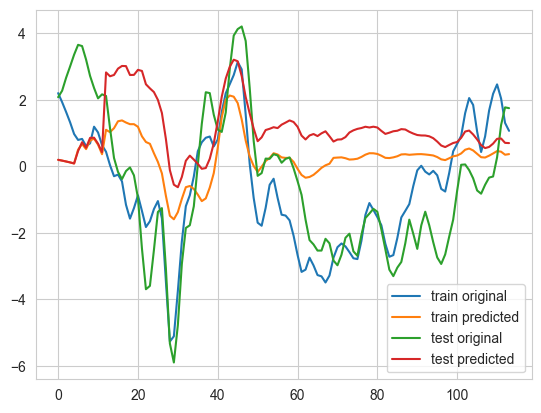

In [143]:
plt.plot(np.mean(train_original_cvs, axis=0), label = 'train original')
plt.plot(np.mean(train_predicted_cvs, axis=0), label = 'train predicted')

plt.plot(np.mean(test_original_cvs, axis=0), label = 'test original')
plt.plot(np.mean(test_predicted_cvs, axis=0), label = 'test predicted')

plt.legend()

0.4875886068341765
-0.00916323762022903


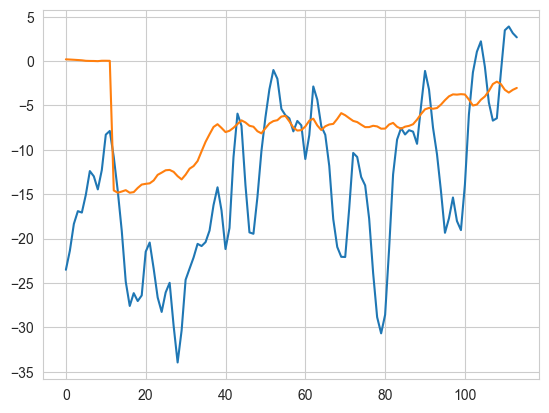

In [144]:
plt.plot(single_trial_train_org)
plt.plot(single_trial_train_pred)

print(np.corrcoef(single_trial_train_org, single_trial_train_pred)[0,1]) # train vs predicted
print(np.corrcoef(single_trial_org, single_trial_pred)[0,1]) # test vs predicted

In [145]:
splits_corrs_train = np.array(splits_corrs_train)
splits_corrs_test = np.array(splits_corrs_test)

Test correlations mean: 0.13216137916870163
Train correlations mean: 0.2139750294250985


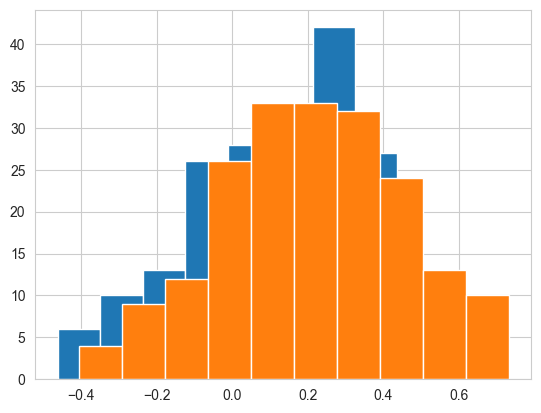

In [147]:
plt.hist(splits_corrs_test.flatten())
plt.hist(splits_corrs_train.flatten())

print(f"Test correlations mean: {np.mean(splits_corrs_test)}")
print(f"Train correlations mean: {np.mean(splits_corrs_train)}")

---
## Compare models

In [15]:
# TODO

In [36]:
# Configure the logger
logging.basicConfig(
    level=logging.INFO,  # Set the logging level
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",  # Format of log messages
    handlers=[
        logging.StreamHandler(sys.stdout)  # Log to standard output
    ]
)

logger = logging.getLogger(__name__)

In [37]:
def calculate_brain_score(
        cv_results,
        test=True,
        crop=(0,0.5),
        sfreq=64,
        epoch_lim = (-0.2, 1.58)
):
    if test:
        variable = 'test'
    else:
        variable = 'train'

    person_results = {}
    for channel in cv_results.keys():
        test_original_cvs = cv_results[channel][f'{variable}_original'].to_numpy()
        test_predicted_cvs = cv_results[channel][f'{variable}_predicted'].to_numpy()

        # epochs: -0.2 to 1.58 ms -> 0 to 114
        if crop is None:
            t_min, t_max = epoch_lim
        else:
            t_min, t_max = crop

        # calculate time window in timepoints
        t_min_tp = int((t_min - epoch_lim[0])*sfreq)
        t_max_tp = int((t_max - epoch_lim[0])*sfreq)

        # iterate over cv repeats
        cv_pearsons_r = []
        for i, (original, predicted) in enumerate(zip(test_original_cvs, test_predicted_cvs)):
            original_cropped = np.array(original)[:, t_min_tp:t_max_tp]
            predicted_cropped = np.array(predicted)[:, t_min_tp:t_max_tp]

            original_cropped_flatten = original_cropped.flatten()
            predicted_cropped_flatten = predicted_cropped.flatten()

            # calculate pearsons r
            r = np.corrcoef(original_cropped_flatten, predicted_cropped_flatten)[0, 1]
            cv_pearsons_r.append(r)

        cv_pearsons_r = np.array(cv_pearsons_r)
        r_mean = cv_pearsons_r.mean()
        r_sd = cv_pearsons_r.std()

        person_results[channel] = {'cv_pearsons_r': cv_pearsons_r, 'cv_mean': r_mean, 'cv_std': r_sd}

    return person_results

In [38]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


Test

In [40]:
file_names = file_names[:6]
results_main_path = '../data/cv_ridge'

unfold_models = ['baseline', 
                 'go', 'stop', 'response', 'full_stop_type', 'full_stop_type_ssd',
                 'full_stop_type_sri', 'full_interactions'
                 ]

models_results_aggregation = []
for file_name in file_names:
    models_pearsons_r = {}
    for model in unfold_models:
        with open(f'{results_main_path}/{model}/{file_name}_cv.pickle', 'rb') as handle:
            cv_results = pickle.load(handle)
            pearsons_r_results = calculate_brain_score(
                cv_results,
                test=True,
                crop=(.7, 1.5)
            )
            models_pearsons_r[model] = pearsons_r_results
    models_results_aggregation.append(models_pearsons_r)

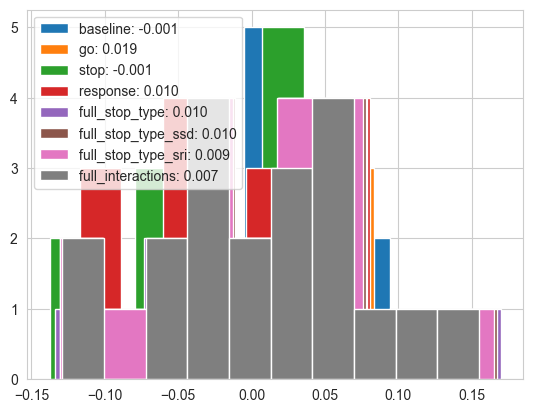

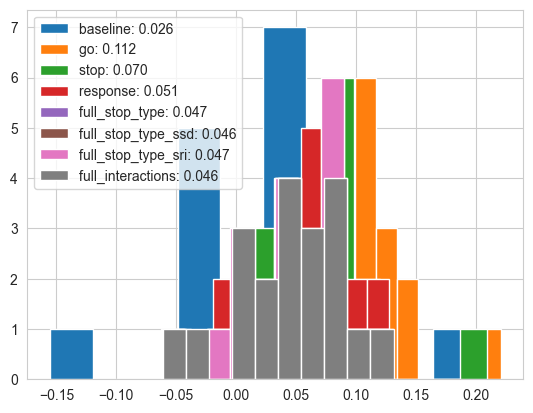

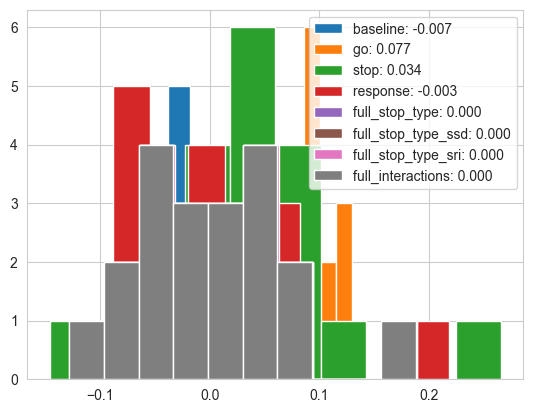

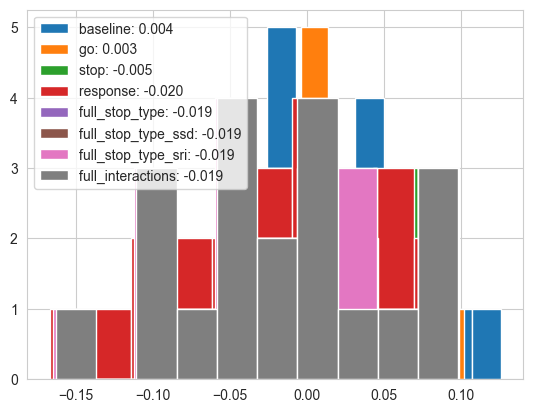

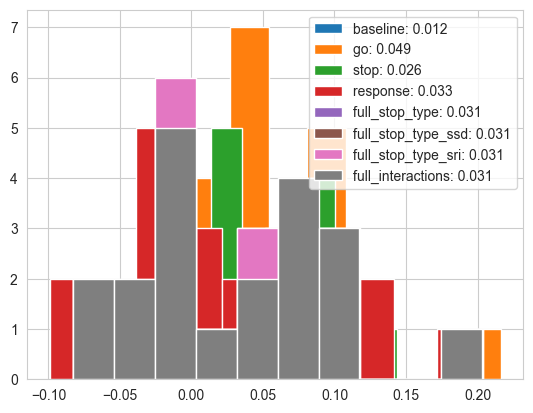

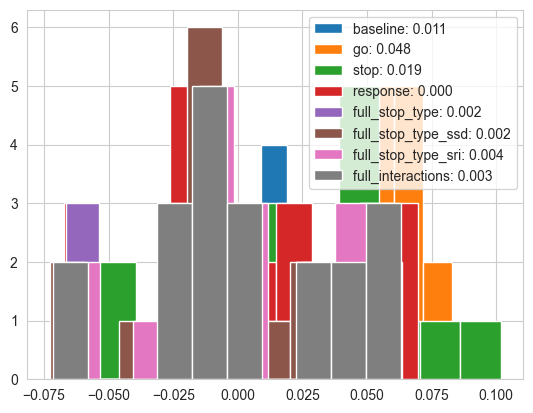

In [41]:
channel = 'Fz'
for i, person_results in enumerate(models_results_aggregation):
    plt.figure(i)
    for model_name, pearsons_r_results in person_results.items():
        data = pearsons_r_results[channel]['cv_pearsons_r']
        plt.hist(data, label=f"{model_name}: {np.mean(data):.3f}")

    plt.legend()

Plot results - within people aggregations

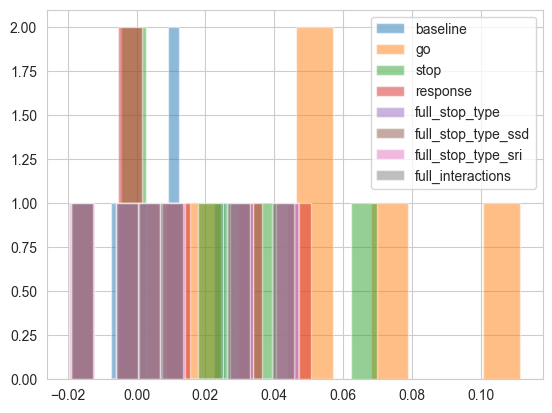

In [42]:
channel = 'Fz'
person_model_agg = {}

# Loop through individual results
for i, person_results in enumerate(models_results_aggregation):
    for model_name, pearsons_r_results in person_results.items():
        # Initialize the list for each model if not already done
        if model_name not in person_model_agg:
            person_model_agg[model_name] = []
        # Append the result for the specific channel
        person_model_agg[model_name].append(pearsons_r_results[channel]['cv_mean'])

# Plot the histograms
for model_name, results in person_model_agg.items():
    plt.hist(results, label=model_name, alpha=0.5)  # Use alpha for better overlay visibility
plt.legend()

#### Train

In [43]:
file_names = file_names[:6]
results_main_path = '../data/cv_ridge'

unfold_models = ['baseline', 'go', 'stop', 'response', 'full_stop_type', 'full_stop_type_ssd',
                 'full_stop_type_sri', 'full_interactions']

models_results_aggregation = []
for file_name in file_names:
    models_pearsons_r = {}
    for model in unfold_models:
        with open(f'{results_main_path}/{model}/{file_name}_cv.pickle', 'rb') as handle:
            cv_results = pickle.load(handle)
            pearsons_r_results = calculate_brain_score(
                cv_results,
                test=False,
                crop=None
            )
            models_pearsons_r[model] = pearsons_r_results
    models_results_aggregation.append(models_pearsons_r)

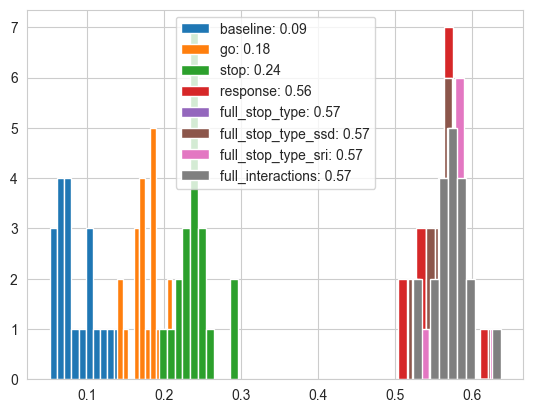

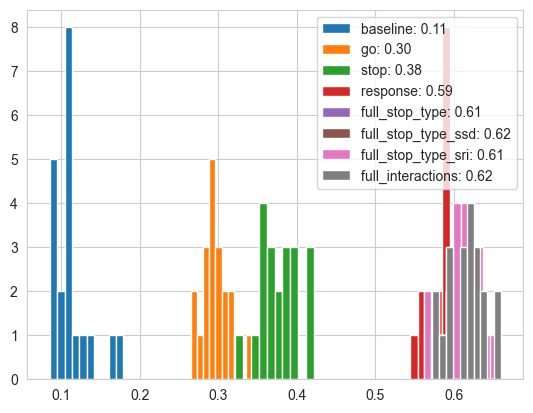

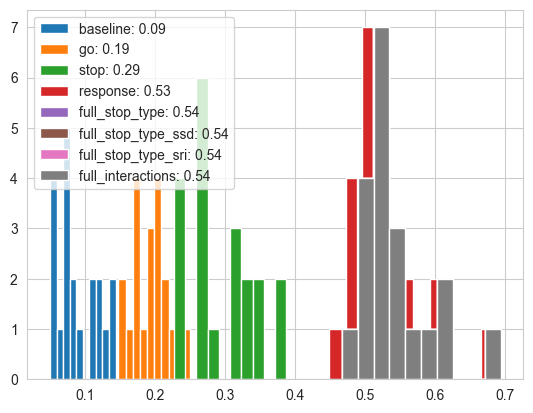

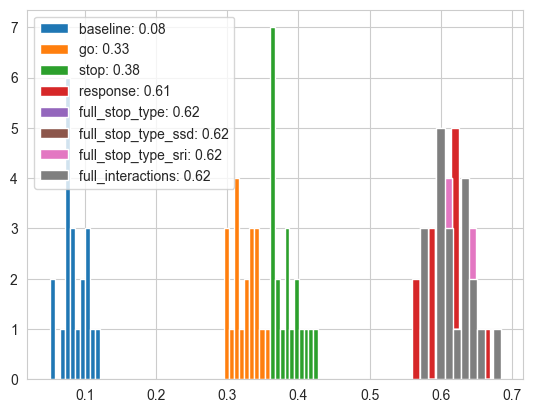

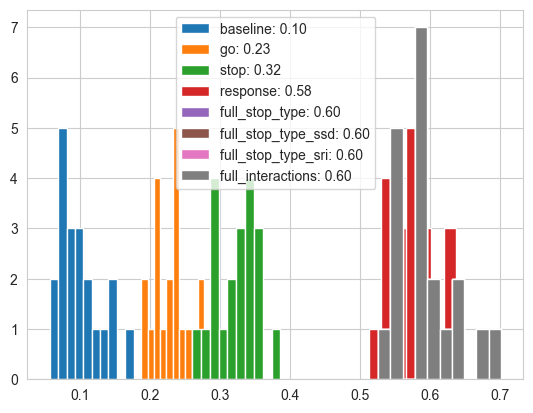

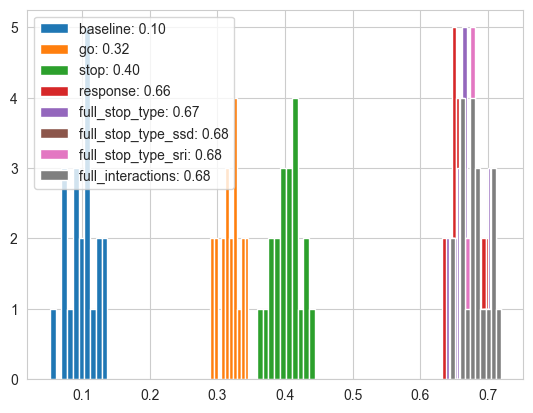

In [44]:
channel = 'Fz'
for i, person_results in enumerate(models_results_aggregation):
    plt.figure(i)
    for model_name, pearsons_r_results in person_results.items():
        data = pearsons_r_results[channel]['cv_pearsons_r']
        plt.hist(data, label=f"{model_name}: {np.mean(data):.2f}")


    plt.legend()

Plot results - within people aggregations


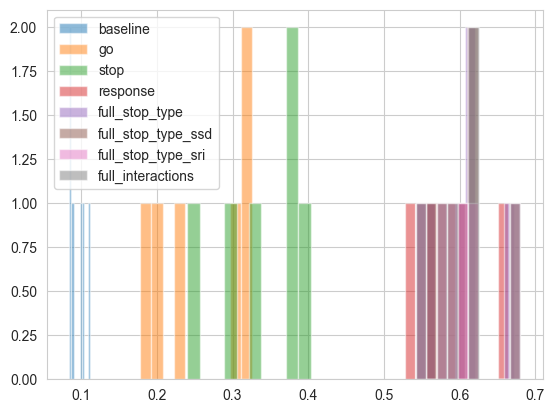

In [45]:
channel = 'Fz'
person_model_agg = {}

# Loop through individual results
for i, person_results in enumerate(models_results_aggregation):
    for model_name, pearsons_r_results in person_results.items():
        # Initialize the list for each model if not already done
        if model_name not in person_model_agg:
            person_model_agg[model_name] = []
        # Append the result for the specific channel
        person_model_agg[model_name].append(pearsons_r_results[channel]['cv_mean'])

# Plot the histograms
for model_name, results in person_model_agg.items():
    plt.hist(results, label=model_name, alpha=0.5)  # Use alpha for better overlay visibility
plt.legend()